# X (Twitter) Sentiment Analysis

### Data Science Internship — Intermediate Task 2

**Objective:** Analyze X data using Natural Language Processing,
statistical analysis, and data visualization to identify sentiment
patterns.

In [ ]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries are working!")

All libraries are working!


In [1]:
import pandas as pd

df = pd.read_csv("X data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Categories:")
print(df["category"].value_counts())

Dataset Shape:
(162980, 2)

Column Names:
Index(['clean_text', 'category'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB

Missing Values:
clean_text    4
category      7
dtype: int64

Sentiment Categories:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [3]:
# Remove rows with missing text or category
df = df.dropna(subset=["clean_text", "category"])

# Check again for missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nNew dataset shape:")
print(df.shape)

Missing values after cleaning:
clean_text    0
category      0
dtype: int64

New dataset shape:
(162969, 2)


In [4]:
# Make sure the text is in string format
df["clean_text"] = df["clean_text"].astype(str)

# Convert text to lowercase
df["clean_text"] = df["clean_text"].str.lower()

# Remove extra spaces
df["clean_text"] = df["clean_text"].str.strip()

# Remove duplicate posts
df = df.drop_duplicates(subset=["clean_text"])

# Check the result
print("Dataset shape after text cleaning:", df.shape)

print("\nSample cleaned text:")
print(df["clean_text"].head())

Dataset shape after text cleaning: (160844, 2)

Sample cleaned text:
0    when modi promised “minimum government maximum...
1    talk all the nonsense and continue all the dra...
2    what did just say vote for modi  welcome bjp t...
3    asking his supporters prefix chowkidar their n...
4    answer who among these the most powerful world...
Name: clean_text, dtype: object


Sentiment Percentage:
category
-1.0    21.841039
 0.0    33.733307
 1.0    44.425655
Name: proportion, dtype: float64


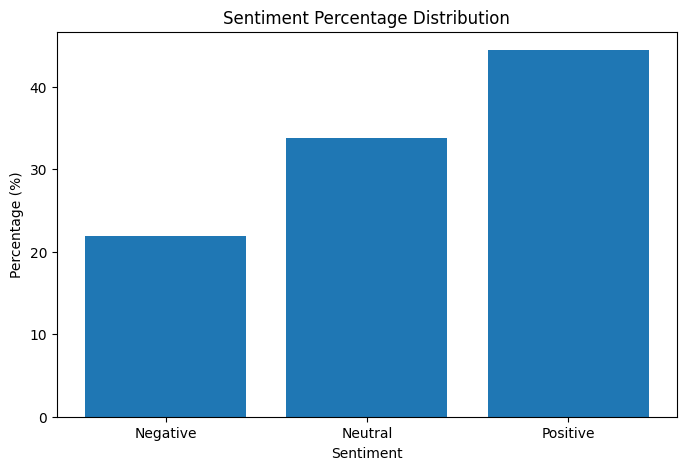

In [8]:
# Calculate sentiment percentages
sentiment_percentage = df["category"].value_counts(normalize=True).sort_index() * 100

# Display percentages
print("Sentiment Percentage:")
print(sentiment_percentage)

# Create a percentage bar chart
labels = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(8, 5))
plt.bar(labels, sentiment_percentage.values)

plt.title("Sentiment Percentage Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")

plt.show()

## Research Questions

1. What is the overall distribution of positive, neutral, and negative sentiments in the X dataset?

2. Which sentiment category is most common among the posts?

3. What are the most frequently used words in the X posts?

4. What words or topics are commonly associated with positive and negative sentiments?

5. How do positive, neutral, and negative sentiments differ in the dataset?

In [9]:
import re

# Function to clean text further for NLP
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # Remove URLs
    text = re.sub(r"@\w+", "", text)             # Remove mentions
    text = re.sub(r"#\w+", "", text)             # Remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)         # Keep letters and spaces
    text = re.sub(r"\s+", " ", text).strip()     # Remove extra spaces
    return text

df["processed_text"] = df["clean_text"].apply(clean_text)

print(df[["clean_text", "processed_text"]].head())

                                          clean_text  \
0  when modi promised “minimum government maximum...   
1  talk all the nonsense and continue all the dra...   
2  what did just say vote for modi  welcome bjp t...   
3  asking his supporters prefix chowkidar their n...   
4  answer who among these the most powerful world...   

                                      processed_text  
0  when modi promised minimum government maximum ...  
1  talk all the nonsense and continue all the dra...  
2  what did just say vote for modi welcome bjp to...  
3  asking his supporters prefix chowkidar their n...  
4  answer who among these the most powerful world...  


In [10]:
from collections import Counter

# Combine all processed text
all_words = " ".join(df["processed_text"])

# Split text into individual words
words = all_words.split()

# Count word frequency
word_counts = Counter(words)

# Display the 20 most common words
print("Top 20 Most Frequent Words:")
print(word_counts.most_common(20))

Top 20 Most Frequent Words:
[('modi', 153595), ('the', 103132), ('and', 66865), ('for', 51840), ('you', 38756), ('not', 29120), ('will', 28695), ('india', 28684), ('this', 28344), ('that', 27947), ('are', 27743), ('with', 20747), ('has', 19875), ('have', 19647), ('but', 18434), ('all', 17799), ('from', 16246), ('his', 16160), ('was', 16159), ('they', 14575)]


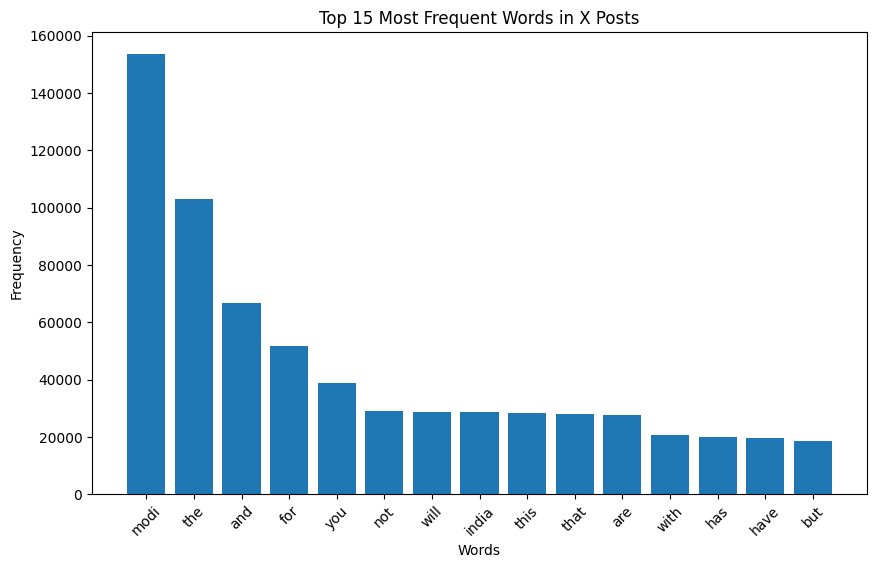

In [11]:
# Get top 15 words
top_words = word_counts.most_common(15)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.title("Top 15 Most Frequent Words in X Posts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [12]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["final_text"] = df["processed_text"].apply(remove_stopwords)

print("Before removing stopwords:")
print(df["processed_text"].head())

print("\nAfter removing stopwords:")
print(df["final_text"].head())

Before removing stopwords:
0    when modi promised minimum government maximum ...
1    talk all the nonsense and continue all the dra...
2    what did just say vote for modi welcome bjp to...
3    asking his supporters prefix chowkidar their n...
4    answer who among these the most powerful world...
Name: processed_text, dtype: object

After removing stopwords:
0    modi promised minimum government maximum gover...
1               talk nonsense continue drama vote modi
2    say vote modi welcome bjp told rahul main camp...
3    asking supporters prefix chowkidar names modi ...
4    answer among powerful world leader today trump...
Name: final_text, dtype: object


In [14]:
from collections import Counter

# Combine all cleaned text
all_words = " ".join(df["final_text"])

# Split into individual words
words = all_words.split()

# Count word frequency
word_counts = Counter(words)

# Display top 20 meaningful words
print("Top 20 Most Frequent Meaningful Words:")
print(word_counts.most_common(20))

Top 20 Most Frequent Meaningful Words:
[('modi', 153595), ('india', 28684), ('bjp', 14516), ('people', 13755), ('congress', 12659), ('like', 12515), ('narendra', 11209), ('govt', 9847), ('one', 9214), ('vote', 9195), ('dont', 8348), ('country', 7759), ('modis', 7635), ('election', 7444), ('years', 7340), ('rahul', 7163), ('time', 7137), ('indian', 6786), ('even', 6704), ('nation', 6702)]


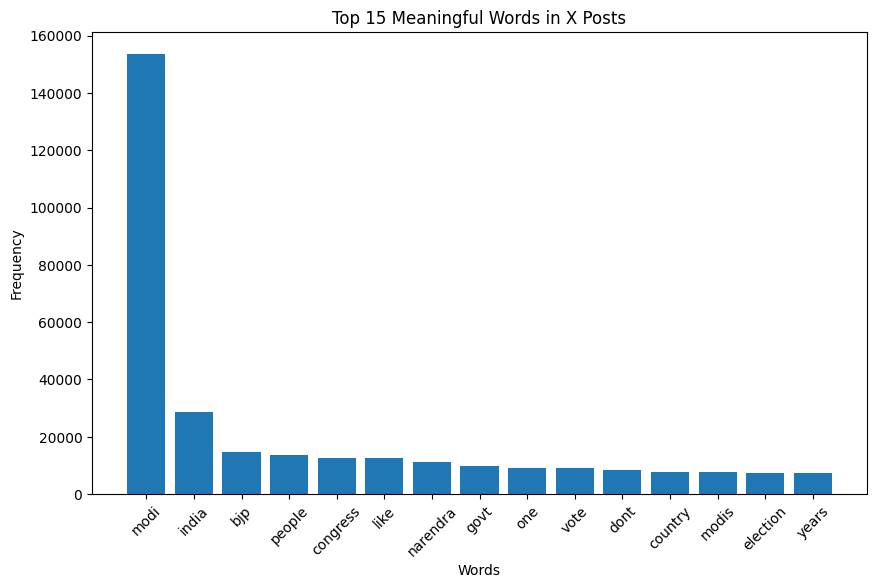

In [15]:
top_words = word_counts.most_common(15)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.title("Top 15 Meaningful Words in X Posts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [16]:
# Separate positive and negative posts
positive_text = " ".join(
    df[df["category"] == 1]["final_text"]
)

negative_text = " ".join(
    df[df["category"] == -1]["final_text"]
)

# Count words
positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())

print("Top 15 words in Positive posts:")
print(positive_words.most_common(15))

print("\nTop 15 words in Negative posts:")
print(negative_words.most_common(15))

Top 15 words in Positive posts:
[('modi', 69732), ('india', 15820), ('bjp', 6998), ('people', 6880), ('like', 6053), ('congress', 5744), ('narendra', 5419), ('one', 4919), ('govt', 4814), ('good', 4768), ('vote', 4400), ('country', 4355), ('nation', 3915), ('time', 3822), ('dont', 3796)]

Top 15 words in Negative posts:
[('modi', 34862), ('india', 6248), ('people', 4042), ('bjp', 3578), ('like', 3426), ('congress', 3412), ('poor', 2600), ('govt', 2597), ('dont', 2330), ('one', 2257), ('even', 2047), ('years', 1994), ('money', 1953), ('hate', 1924), ('country', 1878)]


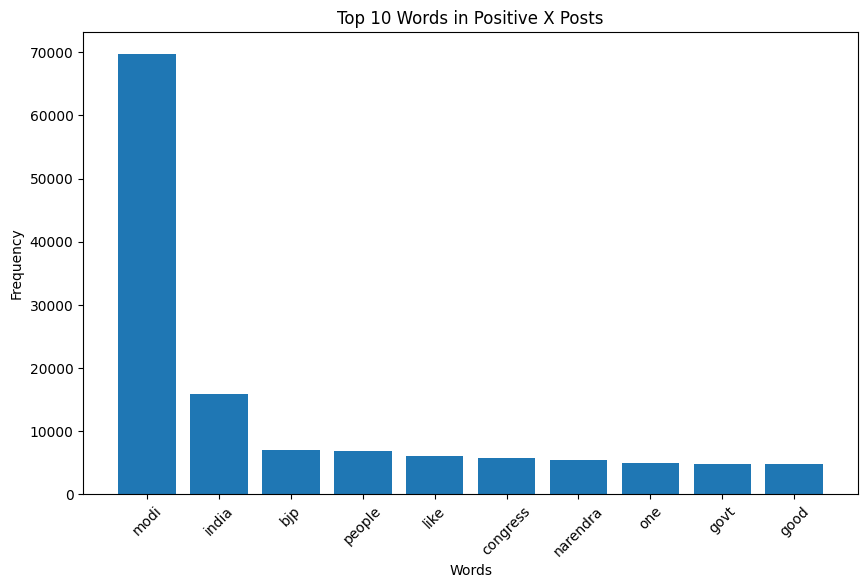

In [17]:
positive_top = positive_words.most_common(10)
negative_top = negative_words.most_common(10)

plt.figure(figsize=(10, 6))

plt.bar(
    [word for word, count in positive_top],
    [count for word, count in positive_top]
)

plt.title("Top 10 Words in Positive X Posts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

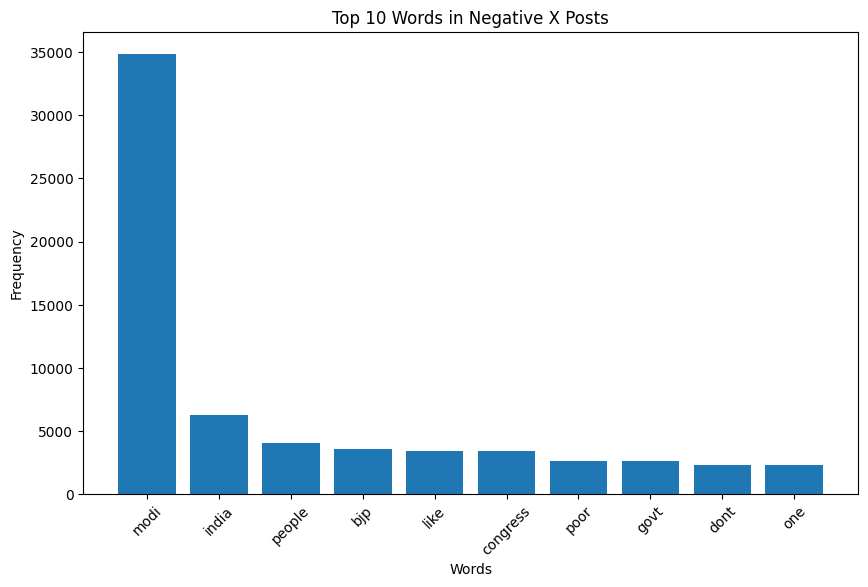

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    [word for word, count in negative_top],
    [count for word, count in negative_top]
)

plt.title("Top 10 Words in Negative X Posts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

Sentiment Percentages:
Negative: 21.84%
Neutral: 33.73%
Positive: 44.43%


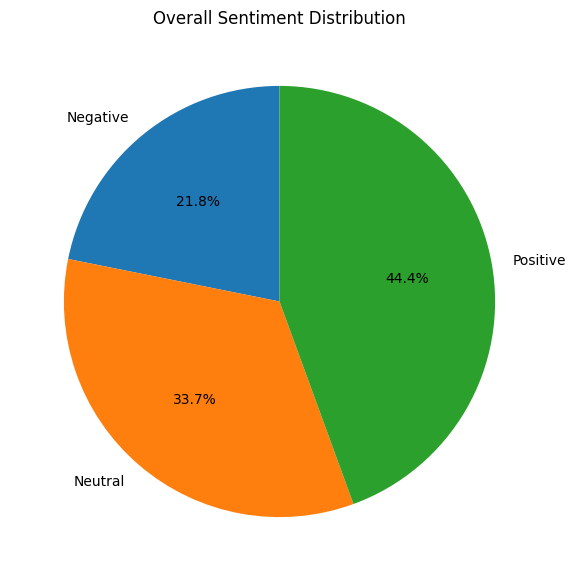

In [19]:
# Calculate sentiment percentages
sentiment_percent = (
    df["category"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

labels = ["Negative", "Neutral", "Positive"]

print("Sentiment Percentages:")
for label, value in zip(labels, sentiment_percent.values):
    print(f"{label}: {value:.2f}%")

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_percent.values,
    labels=labels,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution")
plt.show()

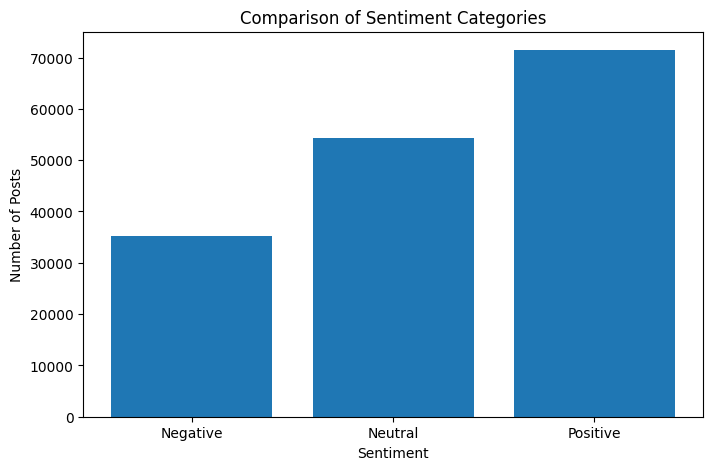

In [20]:
# Sentiment counts
sentiment_counts = df["category"].value_counts().sort_index()

labels = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(8, 5))
plt.bar(labels, sentiment_counts.values)

plt.title("Comparison of Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

plt.show()

## Findings

The sentiment analysis shows that the dataset contains positive, neutral,
and negative X posts.

Positive posts represent the largest sentiment category, followed by
neutral posts. Negative posts represent the smallest of the three
categories.

The word-frequency analysis also helps identify commonly used words in
the dataset and shows differences between positive and negative posts.

These results provide an overview of the prevailing sentiment expressed
in the collected X data.

## Project Summary

This project analyzed X (Twitter) data using Natural Language Processing
and data visualization techniques.

The dataset was cleaned and explored to identify sentiment patterns.
Posts were categorized into Negative, Neutral, and Positive classes.
Word-frequency analysis and visualizations were used to understand the
content and sentiment distribution of the posts.

The analysis demonstrates the use of Python-based data science and NLP
techniques for understanding sentiment in social-media data.

## Conclusion

The sentiment analysis of X data was conducted using Python and Natural
Language Processing techniques.

The dataset was cleaned by removing missing values, duplicate posts,
URLs, mentions, hashtags, unnecessary characters, and common stopwords.

The analysis classified the posts into three sentiment categories:
Negative, Neutral, and Positive.

Statistical analysis and visualizations were used to understand the
distribution of sentiments and identify frequently used words.

The results provide an overview of the sentiments expressed in the X
dataset and demonstrate how NLP and data visualization can be used to
analyze public opinion.

## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- NLTK
- Regular Expressions (re)